In [1]:
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download

DATA_PATH = hf_hub_download(
    repo_id="withmartian/routerbench",
    filename="routerbench_0shot.pkl",
    repo_type="dataset"
)

df = pd.read_pickle(DATA_PATH)

routerbench_0shot.pkl: reconstructing file:   0%|          |  0.00B / 99.6MB            

routerbench_0shot.pkl: downloading bytes:           |  0.00B            

In [3]:
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download

DATA_PATH = hf_hub_download(
    repo_id="withmartian/routerbench",
    filename="routerbench_0shot.pkl",
    repo_type="dataset"
)

df = pd.read_pickle(DATA_PATH)

print(df.shape)

(36497, 37)


In [4]:
MODEL_COLS = [
    "WizardLM/WizardLM-13B-V1.2",
    "claude-instant-v1",
    "claude-v1",
    "claude-v2",
    "gpt-3.5-turbo-1106",
    "gpt-4-1106-preview",
    "meta/code-llama-instruct-34b-chat",
    "meta/llama-2-70b-chat",
    "mistralai/mistral-7b-chat",
    "mistralai/mixtral-8x7b-chat",
    "zero-one-ai/Yi-34B-Chat"
]

print("Models:", len(MODEL_COLS))

Models: 11


In [5]:
mask_mmlu = df["eval_name"].str.startswith("mmlu-", na=False)
mask_arc = df["eval_name"].eq("arc-challenge")
mask_gsm8k = df["eval_name"].eq("grade-school-math")

project_df = df[
    mask_mmlu | mask_arc | mask_gsm8k
].copy()

project_df["domain"] = np.select(
    [
        project_df["eval_name"].str.startswith("mmlu-"),
        project_df["eval_name"].eq("arc-challenge"),
        project_df["eval_name"].eq("grade-school-math")
    ],
    [
        "MMLU",
        "ARC",
        "GSM8K"
    ],
    default="OTHER"
)

print(project_df["domain"].value_counts())
print("Total:", len(project_df))

domain
MMLU     14042
GSM8K     7450
ARC       1470
Name: count, dtype: int64
Total: 22962


In [6]:
COST_COLS = [
    model + "|total_cost"
    for model in MODEL_COLS
]

print("Model columns:", len(MODEL_COLS))
print("Cost columns :", len(COST_COLS))

Model columns: 11
Cost columns : 11


In [7]:
COST_COLS = [
    model + "|total_cost"
    for model in MODEL_COLS
]

print("Model columns:", len(MODEL_COLS))
print("Cost columns :", len(COST_COLS))

for model, cost_col in zip(MODEL_COLS, COST_COLS):
    print(model, " -> ", cost_col)

Model columns: 11
Cost columns : 11
WizardLM/WizardLM-13B-V1.2  ->  WizardLM/WizardLM-13B-V1.2|total_cost
claude-instant-v1  ->  claude-instant-v1|total_cost
claude-v1  ->  claude-v1|total_cost
claude-v2  ->  claude-v2|total_cost
gpt-3.5-turbo-1106  ->  gpt-3.5-turbo-1106|total_cost
gpt-4-1106-preview  ->  gpt-4-1106-preview|total_cost
meta/code-llama-instruct-34b-chat  ->  meta/code-llama-instruct-34b-chat|total_cost
meta/llama-2-70b-chat  ->  meta/llama-2-70b-chat|total_cost
mistralai/mistral-7b-chat  ->  mistralai/mistral-7b-chat|total_cost
mistralai/mixtral-8x7b-chat  ->  mistralai/mixtral-8x7b-chat|total_cost
zero-one-ai/Yi-34B-Chat  ->  zero-one-ai/Yi-34B-Chat|total_cost


In [8]:
X = project_df[
    [
        "sample_id",
        "prompt",
        "domain",
        "eval_name"
    ]
].copy()

print("X shape:", X.shape)

display(X.head())

X shape: (22962, 4)


,sample_id,prompt,domain,eval_name
384,arc-challenge.test.0,['An astronomer observes that a planet rotates...,ARC,arc-challenge
385,arc-challenge.test.1,['A group of engineers wanted to know how diff...,ARC,arc-challenge
386,arc-challenge.test.10,"['According to cell classification, prokaryoti...",ARC,arc-challenge
387,arc-challenge.test.100,['Why does a plastic rod have a negative charg...,ARC,arc-challenge
388,arc-challenge.test.1000,['Some students wanted to make a model to show...,ARC,arc-challenge


In [9]:
Y = project_df[MODEL_COLS].apply(
    pd.to_numeric,
    errors="coerce"
).astype("float32")

print("Y shape:", Y.shape)

print("\nMinimum score:")
print(Y.min().min())

print("\nMaximum score:")
print(Y.max().max())

print("\nMissing values:")
print(Y.isna().sum().sum())

display(Y.head())

Y shape: (22962, 11)

Minimum score:
0.0

Maximum score:
1.0

Missing values:
0


,WizardLM/WizardLM-13B-V1.2,claude-instant-v1,claude-v1,claude-v2,gpt-3.5-turbo-1106,gpt-4-1106-preview,meta/code-llama-instruct-34b-chat,meta/llama-2-70b-chat,mistralai/mistral-7b-chat,mistralai/mixtral-8x7b-chat,zero-one-ai/Yi-34B-Chat
384,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
385,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
386,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
387,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
388,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


In [10]:
C = project_df[COST_COLS].apply(
    pd.to_numeric,
    errors="coerce"
).astype("float32")

# Rename columns so they match Y
C.columns = MODEL_COLS

print("C shape:", C.shape)

print("\nMissing cost values:")
print(C.isna().sum().sum())

print("\nMinimum cost:")
print(C.min().min())

print("\nMaximum cost:")
print(C.max().max())

display(C.head())

C shape: (22962, 11)

Missing cost values:
0

Minimum cost:
9.999999747378752e-06

Maximum cost:
0.023730000481009483


,WizardLM/WizardLM-13B-V1.2,claude-instant-v1,claude-v1,claude-v2,gpt-3.5-turbo-1106,gpt-4-1106-preview,meta/code-llama-instruct-34b-chat,meta/llama-2-70b-chat,mistralai/mistral-7b-chat,mistralai/mixtral-8x7b-chat,zero-one-ai/Yi-34B-Chat
384,0.000027,0.000074,0.000736,0.000736,0.000093,0.00092,0.000071,0.000082,0.000018,0.000055,0.000072
385,0.000032,0.000086,0.000856,0.000856,0.000106,0.00107,0.000082,0.000095,0.000021,0.000064,0.000084
386,0.000026,0.000070,0.000704,0.000704,0.000089,0.00091,0.000068,0.000078,0.000017,0.000052,0.000069
387,0.000027,0.000074,0.000736,0.000736,0.000093,0.00092,0.000071,0.000082,0.000018,0.000055,0.000072
388,0.000028,0.000074,0.000744,0.000744,0.000094,0.00096,0.000071,0.000083,0.000018,0.000055,0.000073


In [11]:
Y_full = (Y == 1.0).astype("int8")

print("Y_full shape:", Y_full.shape)

print("\nPercentage of fully-correct labels:")
print(
    round(
        100 * Y_full.values.mean(),
        2
    ),
    "%"
)

Y_full shape: (22962, 11)

Percentage of fully-correct labels:
34.68 %


In [12]:
assert len(X) == len(Y) == len(C)

assert X.index.equals(Y.index)
assert X.index.equals(C.index)

print("Rows aligned correctly.")

print(
    "Number of questions:",
    len(X)
)

print(
    "Number of candidate LLMs:",
    Y.shape[1]
)

Rows aligned correctly.
Number of questions: 22962
Number of candidate LLMs: 11


In [13]:
X = X.reset_index(drop=True)
Y = Y.reset_index(drop=True)
C = C.reset_index(drop=True)
Y_full = Y_full.reset_index(drop=True)

print(X.shape)
print(Y.shape)
print(C.shape)
print(Y_full.shape)

(22962, 4)
(22962, 11)
(22962, 11)
(22962, 11)


In [14]:
print("===== FINAL DATA CHECK =====")

print("Questions:", len(X))
print("Models:", len(MODEL_COLS))

print(
    "Domains:",
    X["domain"].value_counts().to_dict()
)

print(
    "Y range:",
    Y.min().min(),
    "to",
    Y.max().max()
)

print(
    "C range:",
    C.min().min(),
    "to",
    C.max().max()
)

print(
    "Missing X prompts:",
    X["prompt"].isna().sum()
)

print(
    "Missing Y values:",
    Y.isna().sum().sum()
)

print(
    "Missing C values:",
    C.isna().sum().sum()
)

===== FINAL DATA CHECK =====
Questions: 22962
Models: 11
Domains: {'MMLU': 14042, 'GSM8K': 7450, 'ARC': 1470}
Y range: 0.0 to 1.0
C range: 9.999999747378752e-06 to 0.023730000481009483
Missing X prompts: 0
Missing Y values: 0
Missing C values: 0


In [15]:
canonical_df = X.copy()

for model in MODEL_COLS:
    canonical_df[f"{model}|performance"] = Y[model]
    canonical_df[f"{model}|cost"] = C[model]

canonical_df.to_pickle(
    "/content/router_project_canonical.pkl"
)

print(
    "Saved:",
    "/content/router_project_canonical.pkl"
)

print(
    "Shape:",
    canonical_df.shape
)

Saved: /content/router_project_canonical.pkl
Shape: (22962, 26)


In [16]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [17]:
canonical_df.to_pickle(
    "/content/drive/MyDrive/router_project_canonical.pkl"
)

print("Saved to Google Drive.")

Saved to Google Drive.


In [18]:
#

In [19]:
model_summary = pd.DataFrame({
    "mean_performance": Y.mean(),
    "full_correct_rate": Y_full.mean(),
    "mean_cost": C.mean()
})

model_summary["full_correct_rate"] *= 100

model_summary = model_summary.sort_values(
    "mean_performance",
    ascending=False
)

display(model_summary)

,mean_performance,full_correct_rate,mean_cost
gpt-4-1106-preview,0.771840,55.831374,0.003709
claude-v1,0.668692,45.797404,0.002357
claude-v2,0.654701,44.011846,0.002705
gpt-3.5-turbo-1106,0.645088,44.956885,0.000263
zero-one-ai/Yi-34B-Chat,0.635670,45.884505,0.000199
claude-instant-v1,0.619622,41.681909,0.000264
mistralai/mixtral-8x7b-chat,0.610040,44.599774,0.000141
WizardLM/WizardLM-13B-V1.2,0.476407,31.282118,0.000079
mistralai/mistral-7b-chat,0.313855,18.195279,0.000049
meta/llama-2-70b-chat,0.233059,6.393171,0.000210


In [20]:
best_model = model_summary["mean_performance"].idxmax()
cheapest_model = model_summary["mean_cost"].idxmin()
most_expensive_model = model_summary["mean_cost"].idxmax()

print("Best fixed model:")
print(best_model)

print("\nMean performance:")
print(model_summary.loc[best_model, "mean_performance"])

print("\nMean cost:")
print(model_summary.loc[best_model, "mean_cost"])

print("\n-------------------")

print("Cheapest fixed model:")
print(cheapest_model)

print("\nMean performance:")
print(model_summary.loc[cheapest_model, "mean_performance"])

print("\nMean cost:")
print(model_summary.loc[cheapest_model, "mean_cost"])

print("\n-------------------")

print("Most expensive model:")
print(most_expensive_model)

print("\nMean performance:")
print(model_summary.loc[most_expensive_model, "mean_performance"])

print("\nMean cost:")
print(model_summary.loc[most_expensive_model, "mean_cost"])

Best fixed model:
gpt-4-1106-preview

Mean performance:
0.77184045

Mean cost:
0.0037085628

-------------------
Cheapest fixed model:
mistralai/mistral-7b-chat

Mean performance:
0.3138555

Mean cost:
4.8674094e-05

-------------------
Most expensive model:
gpt-4-1106-preview

Mean performance:
0.77184045

Mean cost:
0.0037085628


In [21]:
import numpy as np

Y_np = Y.to_numpy()
C_np = C.to_numpy()

oracle_choices = []
oracle_scores = []
oracle_costs = []

for i in range(len(Y_np)):
    scores = Y_np[i]
    costs = C_np[i]

    best_score = scores.max()

    candidate_indices = np.where(
        scores == best_score
    )[0]

    cheapest_candidate = candidate_indices[
        np.argmin(costs[candidate_indices])
    ]

    oracle_choices.append(cheapest_candidate)
    oracle_scores.append(scores[cheapest_candidate])
    oracle_costs.append(costs[cheapest_candidate])

oracle_choices = np.array(oracle_choices)
oracle_scores = np.array(oracle_scores)
oracle_costs = np.array(oracle_costs)

print("Oracle mean performance:")
print(oracle_scores.mean())

print("\nOracle mean cost:")
print(oracle_costs.mean())

Oracle mean performance:
0.8904712

Oracle mean cost:
0.0002641071


In [22]:
best_fixed_performance = model_summary.loc[
    best_model,
    "mean_performance"
]

oracle_performance = oracle_scores.mean()

routing_gap = (
    oracle_performance
    - best_fixed_performance
)

print("Best fixed performance:")
print(best_fixed_performance)

print("\nOracle performance:")
print(oracle_performance)

print("\nRouting opportunity gap:")
print(routing_gap)

print("\nGap in percentage points:")
print(routing_gap * 100)

Best fixed performance:
0.77184045

Oracle performance:
0.8904712

Routing opportunity gap:
0.11863077

Gap in percentage points:
11.863077


In [23]:
perfect_count_per_question = Y_full.sum(axis=1)

print("Average number of perfectly-correct models per question:")
print(perfect_count_per_question.mean())

print("\nQuestions where NO model got full score:")
print((perfect_count_per_question == 0).sum())

print("\nQuestions where exactly ONE model got full score:")
print((perfect_count_per_question == 1).sum())

print("\nQuestions where multiple models got full score:")
print((perfect_count_per_question > 1).sum())

print("\nQuestions where ALL models got full score:")
print((perfect_count_per_question == len(MODEL_COLS)).sum())

Average number of perfectly-correct models per question:
3.814998693493598

Questions where NO model got full score:
7841

Questions where exactly ONE model got full score:
1412

Questions where multiple models got full score:
13709

Questions where ALL models got full score:
247


In [24]:
n = len(Y_full)

print(
    "No model full-score:",
    round(
        100 * (perfect_count_per_question == 0).mean(),
        2
    ),
    "%"
)

print(
    "Exactly one model full-score:",
    round(
        100 * (perfect_count_per_question == 1).mean(),
        2
    ),
    "%"
)

print(
    "Multiple models full-score:",
    round(
        100 * (perfect_count_per_question > 1).mean(),
        2
    ),
    "%"
)

print(
    "All models full-score:",
    round(
        100 * (
            perfect_count_per_question
            == len(MODEL_COLS)
        ).mean(),
        2
    ),
    "%"
)

No model full-score: 34.15 %
Exactly one model full-score: 6.15 %
Multiple models full-score: 59.7 %
All models full-score: 1.08 %


In [25]:
domain_results = []

for domain in X["domain"].unique():

    idx = X["domain"] == domain

    for model in MODEL_COLS:

        domain_results.append({
            "domain": domain,
            "model": model,
            "mean_performance": Y.loc[idx, model].mean(),
            "mean_cost": C.loc[idx, model].mean(),
            "full_correct_rate": Y_full.loc[idx, model].mean()
        })

domain_summary = pd.DataFrame(domain_results)

display(
    domain_summary.sort_values(
        ["domain", "mean_performance"],
        ascending=[True, False]
    )
)

,domain,model,mean_performance,mean_cost,full_correct_rate
5,ARC,gpt-4-1106-preview,0.961905,0.000918,0.961905
2,ARC,claude-v1,0.868707,0.000726,0.868707
3,ARC,claude-v2,0.868707,0.000726,0.868707
10,ARC,zero-one-ai/Yi-34B-Chat,0.861224,0.000071,0.861224
9,ARC,mistralai/mixtral-8x7b-chat,0.831973,0.000054,0.831973
4,ARC,gpt-3.5-turbo-1106,0.830612,0.000091,0.830612
1,ARC,claude-instant-v1,0.802721,0.000073,0.802721
7,ARC,meta/llama-2-70b-chat,0.734014,0.000081,0.734014
0,ARC,WizardLM/WizardLM-13B-V1.2,0.610204,0.000027,0.610204
8,ARC,mistralai/mistral-7b-chat,0.387755,0.000018,0.387755


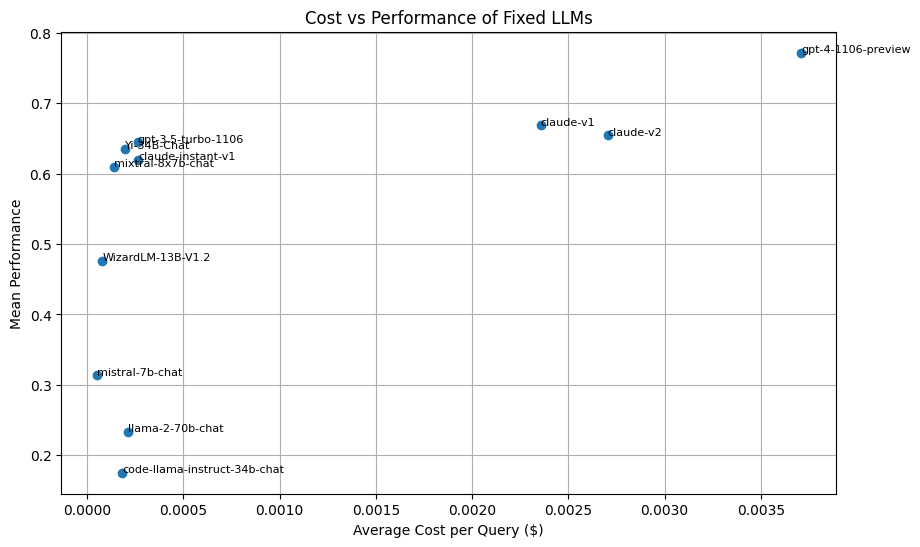

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    model_summary["mean_cost"],
    model_summary["mean_performance"]
)

for model in model_summary.index:
    plt.annotate(
        model.split("/")[-1],
        (
            model_summary.loc[model, "mean_cost"],
            model_summary.loc[model, "mean_performance"]
        ),
        fontsize=8
    )

plt.xlabel("Average Cost per Query ($)")
plt.ylabel("Mean Performance")
plt.title("Cost vs Performance of Fixed LLMs")

plt.grid(True)

plt.show()

In [27]:
#6

In [28]:
print("Duplicate sample IDs:", X["sample_id"].duplicated().sum())
print("Duplicate prompts:", X["prompt"].duplicated().sum())

Duplicate sample IDs: 0
Duplicate prompts: 5


In [29]:
from sklearn.model_selection import train_test_split

all_indices = np.arange(len(X))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=X["domain"]
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=X.loc[temp_idx, "domain"]
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Total:", len(train_idx) + len(val_idx) + len(test_idx))

Train: 18369
Validation: 2296
Test: 2297
Total: 22962


In [30]:
X_train = X.iloc[train_idx].reset_index(drop=True)
X_val   = X.iloc[val_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)

Y_train = Y.iloc[train_idx].reset_index(drop=True)
Y_val   = Y.iloc[val_idx].reset_index(drop=True)
Y_test  = Y.iloc[test_idx].reset_index(drop=True)

C_train = C.iloc[train_idx].reset_index(drop=True)
C_val   = C.iloc[val_idx].reset_index(drop=True)
C_test  = C.iloc[test_idx].reset_index(drop=True)

Y_full_train = Y_full.iloc[train_idx].reset_index(drop=True)
Y_full_val   = Y_full.iloc[val_idx].reset_index(drop=True)
Y_full_test  = Y_full.iloc[test_idx].reset_index(drop=True)

In [31]:
print("TRAIN")
print(X_train.shape, Y_train.shape, C_train.shape)

print("\nVALIDATION")
print(X_val.shape, Y_val.shape, C_val.shape)

print("\nTEST")
print(X_test.shape, Y_test.shape, C_test.shape)

TRAIN
(18369, 4) (18369, 11) (18369, 11)

VALIDATION
(2296, 4) (2296, 11) (2296, 11)

TEST
(2297, 4) (2297, 11) (2297, 11)


In [32]:
def show_domain_distribution(name, frame):
    print(f"\n{name}")
    print(frame["domain"].value_counts())
    print(
        (frame["domain"].value_counts(normalize=True) * 100)
        .round(2)
    )

show_domain_distribution("TRAIN", X_train)
show_domain_distribution("VALIDATION", X_val)
show_domain_distribution("TEST", X_test)


TRAIN
domain
MMLU     11233
GSM8K     5960
ARC       1176
Name: count, dtype: int64
domain
MMLU     61.15
GSM8K    32.45
ARC       6.40
Name: proportion, dtype: float64

VALIDATION
domain
MMLU     1404
GSM8K     745
ARC       147
Name: count, dtype: int64
domain
MMLU     61.15
GSM8K    32.45
ARC       6.40
Name: proportion, dtype: float64

TEST
domain
MMLU     1405
GSM8K     745
ARC       147
Name: count, dtype: int64
domain
MMLU     61.17
GSM8K    32.43
ARC       6.40
Name: proportion, dtype: float64


In [33]:
train_ids = set(X_train["sample_id"])
val_ids = set(X_val["sample_id"])
test_ids = set(X_test["sample_id"])

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [34]:
split_indices = {
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx
}

np.savez(
    "/content/router_split_indices.npz",
    **split_indices
)

print("Saved split indices.")

Saved split indices.


In [35]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
canonical_df.to_pickle(
    "/content/drive/MyDrive/router_project_canonical.pkl"
)

np.savez(
    "/content/drive/MyDrive/router_split_indices.npz",
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx
)

print("Saved canonical dataset and split indices to Drive.")

Saved canonical dataset and split indices to Drive.
